# Multi-Task v2 — Kendall Loss · Rotation-Aware Cobb Sup · Severity Head

Sequel to `multitask_v1` (best val_dice 0.683, cobb_direct MAE 9.34°, cobb_from_kpt MAE 19.69° → kpt path under-trained because it received 0.2% of weighted gradient).

Three changes vs v1:

| # | Change | Reason |
|---|---|---|
| **A** | **Kendall uncertainty-weighted multi-task loss** — learnable `log σ²` per task replaces fixed `(1.0, 1.0, 0.5)` | v1's loss share was 99% seg / 0.2% kpt / 0.8% cobb; auto-balance forces the encoder to actually serve all three heads |
| **B** | **Rotation-aware Cobb supervision** — Cobb magnitude is invariant under affine + flip + intensity aug; only elastic / non-rigid distortions invalidate it | v1 dropped Cobb supervision on every flip (~50% of samples per epoch). Recover it. |
| **D** | **150 epochs · patience 15** | v1 patience never fired and dice was still climbing at epoch 100 |
| **E** | **Severity head** (4-way softmax: normal · mild · moderate · severe) | Free clinical-grade output. Gives a non-Cobb path to severity for ensemble. |

Acceptance: val_dice ≥ 0.683 AND cobb_direct MAE ≤ 9.34°. Stretch: kpt path < 12° MAE (proves it was a balance problem) OR kpt path still bad → drop kpt head in v3.

## 0 · Setup

In [2]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from torchvision.transforms import functional as TF

warnings.filterwarnings("ignore", message=".*lerp.*")

In [3]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")

repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [4]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.preprocessing.keypoints import (
    KEYPOINTS_PER_VERTEBRA,
    TOTAL_KEYPOINTS,
    multiclass_mask_to_keypoints,
)
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.dataset import (
    IMG_H,
    IMG_W,
    TARGET_IDS_V2,
    preprocess_case,
)
from ai.training.augmentation import (
    affine_transform,
    intensity_jitter,
    horizontal_flip,
    elastic_deform,
    gamma_correction,
    gaussian_blur,
    clahe_like,
    gaussian_noise,
    coarse_dropout,
)
from ai.training.losses import seg_loss_fn

NUM_VERT = len(TARGET_IDS_V2)
print(f"size={IMG_H}x{IMG_W}  seg_classes={NUM_SEG_CLASSES}  vertebrae={NUM_VERT}  keypoints={TOTAL_KEYPOINTS}")

size=512x256  seg_classes=18  vertebrae=17  keypoints=68


In [5]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2_corrected" / "clean_index.csv"

def load_clean_index(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{path} missing — run audit generation first")
    return pd.read_csv(path)

def trainable_rows(df: pd.DataFrame, min_vertebrae: int = 14) -> pd.DataFrame:
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = load_clean_index(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
n_with_cobb = TRAINABLE["cobb_angle_deg"].notna().sum()
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)} (cobb_gt={n_with_cobb})  train={len(TRAIN_DF)}  val={len(VAL_DF)}")

total=250  trainable=249 (cobb_gt=178)  train=199  val=50


## 1 · Severity Buckets

Standard scoliosis grading: `normal <10° · mild 10–25° · moderate 25–40° · severe ≥40°`. Used by both the **severity head** target and the eval-time mapping from each Cobb estimator.

In [6]:
SEVERITY_BUCKETS = (("normal", 0.0, 10.0), ("mild", 10.0, 25.0),
                    ("moderate", 25.0, 40.0), ("severe", 40.0, 999.0))
SEVERITY_LABELS = [n for n, _, _ in SEVERITY_BUCKETS]
NUM_SEVERITY = len(SEVERITY_LABELS)

def severity_label(angle: float) -> int:
    for i, (_, lo, hi) in enumerate(SEVERITY_BUCKETS):
        if lo <= angle < hi:
            return i
    return -1  # unknown

def severity_name(angle: float) -> str:
    i = severity_label(angle)
    return SEVERITY_LABELS[i] if i >= 0 else "unknown"

for name, lo, hi in SEVERITY_BUCKETS:
    print(f"  {name:9s} {lo:6.1f}° – {hi:6.1f}°")

  normal       0.0° –   10.0°
  mild        10.0° –   25.0°
  moderate    25.0° –   40.0°
  severe      40.0° –  999.0°


## 2 · Heatmap Rendering

In [7]:
HEATMAP_DOWNSAMPLE = 4
HM_H = IMG_H // HEATMAP_DOWNSAMPLE  # 128
HM_W = IMG_W // HEATMAP_DOWNSAMPLE  # 64
HEATMAP_SIGMA = 2.0

def render_heatmaps(
    keypoints_xy_full: np.ndarray,
    h: int = HM_H, w: int = HM_W,
    downsample: int = HEATMAP_DOWNSAMPLE,
    sigma: float = HEATMAP_SIGMA,
) -> tuple[np.ndarray, np.ndarray]:
    k = keypoints_xy_full.shape[0]
    hm = np.zeros((k, h, w), dtype=np.float32)
    valid = np.zeros((k,), dtype=bool)
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    for i in range(k):
        x_full, y_full = keypoints_xy_full[i]
        if not (np.isfinite(x_full) and np.isfinite(y_full)):
            continue
        cx, cy = x_full / downsample, y_full / downsample
        hm[i] = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma ** 2))
        valid[i] = True
    return hm, valid

def keypoints_from_heatmaps(hm: torch.Tensor, threshold: float = 0.1, upsample: int = HEATMAP_DOWNSAMPLE):
    k, h, w = hm.shape
    flat = hm.reshape(k, -1)
    scores, idx = flat.max(dim=1)
    ys = (idx // w).float() * upsample
    xs = (idx % w).float() * upsample
    coords = torch.stack([xs, ys], dim=1).cpu().numpy()
    s = scores.cpu().numpy()
    coords[s < threshold] = np.nan
    return coords, s

## 3 · Cobb-Preserving Augmentation

Cobb angle = max pairwise tilt between vertebra endplates.

| Transform | Cobb magnitude preserved? | Reason |
|---|---|---|
| Affine (rot / translate / scale) | **yes** | rotation rotates every endplate equally → pairwise differences unchanged |
| Horizontal flip | **yes** | all signs flip → \|differences\| identical |
| Intensity jitter / gamma / blur / noise / dropout / clahe | **yes** | image-only |
| **Elastic deformation** | **NO** | non-rigid, distorts spine geometry locally |

v1 masked Cobb supervision on every horizontal flip (~50 % of supervised samples lost). v2 only masks Cobb when an elastic warp fires (~40 % chance per case). Net gain: roughly +50 % Cobb-supervised samples per epoch.

In [8]:
def augment_v5_cobb_aware(
    image: torch.Tensor, seg: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor, bool]:
    """Same intensity / spatial chain as augment_v4, but returns a third value:
    `cobb_preserved` — False iff a non-rigid (elastic) warp fired this call."""
    cobb_preserved = True

    if torch.rand(1).item() < 0.7:
        image, seg = affine_transform(
            image, seg,
            angle_range=(-15.0, 15.0),
            translate_frac=0.10,
            scale_range=(0.85, 1.15),
        )
    if torch.rand(1).item() < 0.5:
        image, seg = horizontal_flip(image, seg)
    if torch.rand(1).item() < 0.4:
        image, seg = elastic_deform(image, seg, alpha=40.0, sigma=6.0)
        cobb_preserved = False  # only line that differs from augment_v4
    if torch.rand(1).item() < 0.5:
        image = intensity_jitter(image, gain_range=(0.7, 1.3), bias_range=(-0.15, 0.15))
    if torch.rand(1).item() < 0.3:
        image = gamma_correction(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_blur(image)
    if torch.rand(1).item() < 0.2:
        image = clahe_like(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_noise(image, std_range=(0.0, 0.08))
    if torch.rand(1).item() < 0.25:
        image = coarse_dropout(image, n_patches=12, patch_size=40)
    return image, seg, cobb_preserved

## 4 · Multi-Task Dataset (v2)

Returns six tensors per sample. Cobb GT is preserved through all rigid + intensity augmentations and only masked when elastic fires.

In [9]:
class MultiTaskSpineDatasetV2(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        augment: bool = False,
        target_ids: tuple[int, ...] = TARGET_IDS_V2,
    ):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.target_ids = target_ids

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, i: int) -> dict[str, torch.Tensor]:
        row = self.df.iloc[i]
        case = preprocess_case(row, target_ids=self.target_ids)
        image, seg = case["image"], case["seg"]

        cobb_preserved = True
        if self.augment:
            image, seg, cobb_preserved = augment_v5_cobb_aware(image, seg)

        # re-extract keypoints from possibly-augmented seg
        seg_np = seg.numpy().astype(np.uint8)
        raw = np.zeros_like(seg_np)
        for k_idx, raw_id in enumerate(self.target_ids, start=1):
            raw[seg_np == k_idx] = raw_id
        kps_full = multiclass_mask_to_keypoints(raw, target_ids=self.target_ids)
        hm, valid = render_heatmaps(kps_full)

        gt = row.get("cobb_angle_deg")
        has_gt = pd.notna(gt) and cobb_preserved
        if has_gt:
            cobb_t = torch.tensor(float(gt), dtype=torch.float32)
            sev_t = torch.tensor(severity_label(float(gt)), dtype=torch.long)
        else:
            cobb_t = torch.tensor(0.0, dtype=torch.float32)
            sev_t = torch.tensor(-1, dtype=torch.long)
        valid_flag = torch.tensor(has_gt)

        return {
            "image": image,
            "seg": seg,
            "kpt_heatmap": torch.from_numpy(hm),
            "kpt_valid": torch.from_numpy(valid),
            "cobb": cobb_t,
            "cobb_valid": valid_flag,
            "sev": sev_t,
            "sev_valid": valid_flag,
        }


def multitask_collate(batch: list[dict]) -> dict[str, torch.Tensor]:
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}

_ds = MultiTaskSpineDatasetV2(TRAIN_DF.head(4), augment=True)
_b = multitask_collate([_ds[i] for i in range(4)])
for k, v in _b.items():
    print(f"  {k:14s}  {tuple(v.shape)}  {v.dtype}")

  image           (4, 1, 512, 256)  torch.float32
  seg             (4, 512, 256)  torch.int64
  kpt_heatmap     (4, 68, 128, 64)  torch.float32
  kpt_valid       (4, 68)  torch.bool
  cobb            (4,)  torch.float32
  cobb_valid      (4,)  torch.bool
  sev             (4,)  torch.int64
  sev_valid       (4,)  torch.bool


## 5 · Multi-Task Architecture (v2)

Same backbone as v1, with one extra head:

- **Seg head**, **Kpt head**, **Cobb head** — unchanged
- **Severity head** — bottleneck GAP → MLP → 4-way logits

In [10]:
def _conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
    )

class _Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        dy = skip.shape[2] - x.shape[2]; dx = skip.shape[3] - x.shape[3]
        if dy != 0 or dx != 0:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x, skip], dim=1))


class MultiTaskEncoderUNetV2(nn.Module):
    def __init__(
        self,
        in_ch: int = 1,
        num_seg_classes: int = NUM_SEG_CLASSES,
        num_keypoints: int = TOTAL_KEYPOINTS,
        num_severity: int = NUM_SEVERITY,
        pretrained: bool = True,
        dropout: float = 0.2,
        cobb_norm: float = 90.0,
    ):
        super().__init__()
        self.cobb_norm = cobb_norm

        weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet34(weights=weights)
        original_conv1 = backbone.conv1
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained and in_ch == 1:
            self.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)
        elif pretrained and in_ch == 3:
            self.conv1.weight.data = original_conv1.weight.data

        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.up1 = _Up(512, 256, 256)
        self.up2 = _Up(256, 128, 128)
        self.up3 = _Up(128, 64, 64)
        self.up4 = _Up(64, 64, 64)
        self.final_up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.drop = nn.Dropout2d(dropout)

        self.seg_head = nn.Conv2d(64, num_seg_classes, 1)
        self.kpt_head = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, num_keypoints, 1),
        )
        self.cobb_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )
        self.sev_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 64), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(64, num_severity),
        )

        self._encoder_modules = [
            self.conv1, self.bn1, self.layer1, self.layer2, self.layer3, self.layer4,
        ]
        self._decoder_modules = [
            self.up1, self.up2, self.up3, self.up4, self.final_up, self.drop,
            self.seg_head, self.kpt_head, self.cobb_head, self.sev_head,
        ]

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))
        s1 = self.layer1(self.maxpool(x0))
        s2 = self.layer2(s1); s3 = self.layer3(s2); bridge = self.layer4(s3)
        y = self.up1(bridge, s3); y = self.up2(y, s2)
        y_q = self.up3(y, s1); y = self.up4(y_q, x0)
        y_full = self.drop(self.final_up(y))
        return {
            "seg":  self.seg_head(y_full),
            "kpt":  self.kpt_head(y_q),
            "cobb": (self.cobb_head(bridge).squeeze(-1)) * self.cobb_norm,
            "sev":  self.sev_head(bridge),
        }

    def encoder_params(self):
        for m in self._encoder_modules: yield from m.parameters()
    def decoder_params(self):
        for m in self._decoder_modules: yield from m.parameters()


def count_params(m): return sum(p.numel() for p in m.parameters())
model = MultiTaskEncoderUNetV2(pretrained=True).to(DEVICE)
print(f"MultiTaskEncoderUNetV2 params: {count_params(model):,}")
with torch.no_grad():
    out = model(_b["image"].to(DEVICE))
for k, v in out.items():
    print(f"  {k:5s} {tuple(v.shape)}")

Dropped Escape call with ulEscapeCode : 0x03007703


MultiTaskEncoderUNetV2 params: 24,534,395
  seg   (4, 18, 512, 256)
  kpt   (4, 68, 128, 64)
  cobb  (4,)
  sev   (4, 4)


## 6 · Kendall Uncertainty-Weighted Multi-Task Loss

Kendall, Gal & Cipolla (2018). Each task gets a learnable `log σ²ᵢ`. Total loss:

$$\mathcal{L} = \sum_i \frac{1}{2\sigma_i^2}\,\mathcal{L}_i + \log \sigma_i$$

Implemented in log-variance form for numerical stability. `log_var_i` is initialized to 0 (σ=1) for all four tasks. The model **learns its own loss balance** during training. The regularizer `0.5·log_var` prevents `σ → ∞`.

Replaces v1's fixed `(λ_seg, λ_kpt, λ_cobb) = (1.0, 1.0, 0.5)`.

In [11]:
COBB_NORM = 90.0

class KendallMultiTaskLoss(nn.Module):
    def __init__(self, task_names: tuple[str, ...] = ("seg", "kpt", "cobb", "sev")):
        super().__init__()
        self.task_names = task_names
        self.log_var = nn.Parameter(torch.zeros(len(task_names)))

    def forward(self, raw_losses: dict[str, torch.Tensor]) -> tuple[torch.Tensor, dict[str, float]]:
        total = 0.0
        parts: dict[str, float] = {}
        for i, name in enumerate(self.task_names):
            lv = self.log_var[i]
            li = raw_losses[name]
            term = 0.5 * torch.exp(-lv) * li + 0.5 * lv
            total = total + term
            parts[f"raw_{name}"] = float(li.detach().cpu())
            parts[f"log_var_{name}"] = float(lv.detach().cpu())
            parts[f"weight_{name}"] = float((0.5 * torch.exp(-lv)).detach().cpu())
        return total, parts

def kpt_loss_fn(pred, target, valid):
    mask = valid.float().unsqueeze(-1).unsqueeze(-1)
    diff = (pred - target) ** 2 * mask
    denom = mask.sum() * pred.shape[-1] * pred.shape[-2] + 1e-6
    return diff.sum() / denom

def cobb_loss_fn(pred_deg, target_deg, valid, norm: float = COBB_NORM):
    if not bool(valid.any()):
        return pred_deg.sum() * 0.0
    p = pred_deg[valid] / norm; t = target_deg[valid] / norm
    return F.smooth_l1_loss(p, t)

def sev_loss_fn(logits, target, valid):
    if not bool(valid.any()):
        return logits.sum() * 0.0
    return F.cross_entropy(logits[valid], target[valid])

def raw_losses_for(out: dict, batch: dict, dev) -> dict[str, torch.Tensor]:
    return {
        "seg":  seg_loss_fn(out["seg"], batch["seg"].to(dev), NUM_SEG_CLASSES),
        "kpt":  kpt_loss_fn(out["kpt"], batch["kpt_heatmap"].to(dev), batch["kpt_valid"].to(dev)),
        "cobb": cobb_loss_fn(out["cobb"], batch["cobb"].to(dev), batch["cobb_valid"].to(dev)),
        "sev":  sev_loss_fn(out["sev"], batch["sev"].to(dev), batch["sev_valid"].to(dev)),
    }

## 7 · Training Loop

In [12]:
import hashlib
import json
from datetime import datetime

CHECKPOINT_ROOT = REPO_ROOT / "ai" / "models" / "checkpoints" / "multitask_v2"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS = 150
BATCH_SIZE = 4
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
LR_LOGVAR = 1e-3
WEIGHT_DECAY = 2e-4
WARMUP_EPOCHS = 10
PATIENCE = 15
DROPOUT = 0.2
ENCODER_NAME = "resnet34"

def run_config() -> dict:
    return {
        "dataset": "v2_corrected",
        "arch": "MultiTaskEncoderUNetV2",
        "encoder": ENCODER_NAME,
        "num_seg_classes": NUM_SEG_CLASSES,
        "num_keypoints": TOTAL_KEYPOINTS,
        "num_severity": NUM_SEVERITY,
        "heatmap_h": HM_H, "heatmap_w": HM_W, "heatmap_sigma": HEATMAP_SIGMA,
        "loss": "kendall_uncertainty",
        "cobb_norm": COBB_NORM,
        "augment": "v5_cobb_aware",
        "num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE,
        "lr_encoder": LR_ENCODER, "lr_decoder": LR_DECODER, "lr_logvar": LR_LOGVAR,
        "weight_decay": WEIGHT_DECAY, "warmup_epochs": WARMUP_EPOCHS,
        "patience": PATIENCE, "dropout": DROPOUT, "seed": SEED,
        "trainable_count": int(len(TRAINABLE)), "val_frac": 0.2,
    }

def cfg_hash(cfg): return hashlib.sha256(json.dumps(cfg, sort_keys=True, default=str).encode()).hexdigest()[:8]
def find_cached(cfg):
    h = cfg_hash(cfg)
    for p in sorted(CHECKPOINT_ROOT.glob(f"*_{h}")):
        if (p / "model.pt").exists(): return p
    return None
def new_run_dir(cfg):
    p = CHECKPOINT_ROOT / f"{datetime.now().strftime('%Y%m%dT%H%M')}_{cfg_hash(cfg)}"
    p.mkdir(parents=True, exist_ok=True); return p

In [13]:
@torch.no_grad()
def validate(model, loss_module, loader):
    model.eval()
    accum = {"loss": 0.0,
             "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0, "raw_sev": 0.0,
             "weight_seg": 0.0, "weight_kpt": 0.0, "weight_cobb": 0.0, "weight_sev": 0.0}
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card  = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    cobb_abs: list[float] = []
    sev_correct = 0; sev_total = 0
    n = 0
    for batch in loader:
        out = model(batch["image"].to(DEVICE))
        raws = raw_losses_for(out, batch, DEVICE)
        total, parts = loss_module(raws)
        accum["loss"] += float(total.detach().cpu())
        for k in ("raw_seg", "raw_kpt", "raw_cobb", "raw_sev"): accum[k] += parts[k]
        for k in ("weight_seg", "weight_kpt", "weight_cobb", "weight_sev"): accum[k] += parts[k]
        pm = out["seg"].argmax(dim=1); seg_t = batch["seg"].to(DEVICE)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pm == c), (seg_t == c)
            inter[c - 1] += (p & g).sum(); card[c - 1] += p.sum() + g.sum()
        v = batch["cobb_valid"]
        if v.any():
            cobb_abs.extend((out["cobb"].cpu()[v] - batch["cobb"][v]).abs().tolist())
        sv = batch["sev_valid"]
        if sv.any():
            pred = out["sev"].cpu()[sv].argmax(dim=1)
            sev_correct += int((pred == batch["sev"][sv]).sum()); sev_total += int(sv.sum())
        n += 1
    dice_per = (2.0 * inter) / card.clamp(min=1e-6)
    valid_cls = card > 0
    return {
        **{k: v / max(1, n) for k, v in accum.items()},
        "dice": float(dice_per[valid_cls].mean()) if valid_cls.any() else float("nan"),
        "cobb_mae_direct": float(np.mean(cobb_abs)) if cobb_abs else float("nan"),
        "sev_acc": (sev_correct / sev_total) if sev_total else float("nan"),
    }

In [14]:
cfg = run_config()
_cached = find_cached(cfg)
loss_module = KendallMultiTaskLoss().to(DEVICE)

if _cached is not None:
    state = torch.load(_cached / "model.pt", map_location=DEVICE)
    history_df = pd.read_csv(_cached / "history.csv")
    metrics_cache = json.loads((_cached / "metrics.json").read_text())
    model = MultiTaskEncoderUNetV2(pretrained=False, dropout=DROPOUT).to(DEVICE)
    model.load_state_dict(state["model"])
    loss_module.load_state_dict(state["loss_module"])
    best_dice = float(metrics_cache["best_val_dice"])
    print(f"reused cached run <- {_cached.relative_to(REPO_ROOT)}, best val_dice={best_dice:.3f}")
else:
    model = MultiTaskEncoderUNetV2(pretrained=True, dropout=DROPOUT).to(DEVICE)
    print(f"params: {count_params(model):,} (loss σ params: {sum(p.numel() for p in loss_module.parameters())})")

    train_loader = DataLoader(MultiTaskSpineDatasetV2(TRAIN_DF, augment=True),  batch_size=BATCH_SIZE, shuffle=True,  collate_fn=multitask_collate)
    val_loader   = DataLoader(MultiTaskSpineDatasetV2(VAL_DF,   augment=False), batch_size=BATCH_SIZE, shuffle=False, collate_fn=multitask_collate)

    for p in model.encoder_params(): p.requires_grad = False
    optimizer = torch.optim.Adam([
        {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
        {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
    ])
    scheduler = None

    history: list[dict] = []
    best_dice = -1.0
    best_state = None
    no_improve = 0

    t_start = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        if epoch == WARMUP_EPOCHS + 1:
            for p in model.encoder_params(): p.requires_grad = True
            optimizer = torch.optim.Adam([
                {"params": model.encoder_params(), "lr": LR_ENCODER, "weight_decay": WEIGHT_DECAY},
                {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
                {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
            ])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS)
            print(f"  >>> encoder unfrozen at epoch {epoch}")

        model.train()
        train_acc = {"loss": 0.0, "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0, "raw_sev": 0.0}
        n_steps = 0
        for batch in train_loader:
            out = model(batch["image"].to(DEVICE))
            raws = raw_losses_for(out, batch, DEVICE)
            total, parts = loss_module(raws)
            optimizer.zero_grad(); total.backward(); optimizer.step()
            train_acc["loss"] += float(total.detach().cpu())
            for k in ("raw_seg", "raw_kpt", "raw_cobb", "raw_sev"): train_acc[k] += parts[k]
            n_steps += 1
        train_acc = {k: v / max(1, n_steps) for k, v in train_acc.items()}

        val_stats = validate(model, loss_module, val_loader)
        if scheduler is not None: scheduler.step()

        n_groups = len(optimizer.param_groups)
        row = {
            "epoch":      epoch,
            "train_loss": train_acc["loss"], "train_seg": train_acc["raw_seg"],
            "train_kpt":  train_acc["raw_kpt"], "train_cobb": train_acc["raw_cobb"], "train_sev": train_acc["raw_sev"],
            "val_loss":   val_stats["loss"],
            "val_seg":    val_stats["raw_seg"], "val_kpt": val_stats["raw_kpt"],
            "val_cobb":   val_stats["raw_cobb"], "val_sev": val_stats["raw_sev"],
            "w_seg":      val_stats["weight_seg"], "w_kpt": val_stats["weight_kpt"],
            "w_cobb":     val_stats["weight_cobb"], "w_sev": val_stats["weight_sev"],
            "val_dice":   val_stats["dice"],
            "val_cobb_mae": val_stats["cobb_mae_direct"], "val_sev_acc": val_stats["sev_acc"],
            "lr_enc":     float(optimizer.param_groups[0]["lr"]) if n_groups > 2 else 0.0,
            "lr_dec":     float(optimizer.param_groups[-2]["lr"]) if n_groups >= 2 else float(optimizer.param_groups[0]["lr"]),
            "sec":        time.time() - t0,
        }
        history.append(row)

        if val_stats["dice"] > best_dice:
            best_dice = val_stats["dice"]
            best_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "loss_module": {k: v.detach().cpu().clone() for k, v in loss_module.state_dict().items()},
            }
            no_improve = 0
        else:
            no_improve += 1

        tag = " *" if no_improve == 0 else ""
        print(
            f"ep {epoch:3d}/{NUM_EPOCHS}  "
            f"tr={row['train_loss']:6.3f}  val={row['val_loss']:6.3f}  "
            f"dice={row['val_dice']:.3f}  cobb={row['val_cobb_mae']:5.1f}°  sev={row['val_sev_acc']:.2f}  "
            f"w[s/k/c/v]={row['w_seg']:.2f}/{row['w_kpt']:.2f}/{row['w_cobb']:.2f}/{row['w_sev']:.2f}  "
            f"({row['sec']:.1f}s){tag}"
        )

        if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
            print(f"\n  >>> early stop at epoch {epoch}, no improvement for {PATIENCE} epochs")
            break

    if best_state is not None:
        model.load_state_dict(best_state["model"])
        loss_module.load_state_dict(best_state["loss_module"])
    history_df = pd.DataFrame(history)

    run_dir = new_run_dir(cfg)
    torch.save({
        "model": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        "loss_module": {k: v.detach().cpu() for k, v in loss_module.state_dict().items()},
    }, run_dir / "model.pt")
    history_df.to_csv(run_dir / "history.csv", index=False)
    (run_dir / "config.json").write_text(json.dumps(cfg, indent=2, default=str))
    (run_dir / "metrics.json").write_text(json.dumps({
        "best_val_dice": best_dice,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
        "final_log_var": loss_module.log_var.detach().cpu().tolist(),
    }, indent=2))
    print(f"\ntotal time: {time.time() - t_start:.1f}s  best val_dice={best_dice:.3f}")
    print(f"saved -> {run_dir.relative_to(REPO_ROOT)}")

params: 24,534,395 (loss σ params: 4)
ep   1/150  tr= 0.959  val= 1.173  dice=0.000  cobb= 29.8°  sev=0.81  w[s/k/c/v]=0.48/0.53/0.53/0.51  (14.6s) *
ep   2/150  tr= 0.769  val= 0.892  dice=0.047  cobb= 17.2°  sev=0.81  w[s/k/c/v]=0.46/0.55/0.55/0.53  (14.4s) *
ep   3/150  tr= 0.667  val= 0.730  dice=0.122  cobb= 17.3°  sev=0.81  w[s/k/c/v]=0.46/0.58/0.58/0.54  (18.1s) *
ep   4/150  tr= 0.571  val= 0.518  dice=0.189  cobb= 18.0°  sev=0.81  w[s/k/c/v]=0.46/0.61/0.61/0.55  (13.7s) *
ep   5/150  tr= 0.517  val= 0.515  dice=0.130  cobb= 21.7°  sev=0.81  w[s/k/c/v]=0.46/0.64/0.64/0.57  (17.4s)
ep   6/150  tr= 0.472  val= 0.375  dice=0.215  cobb= 16.7°  sev=0.81  w[s/k/c/v]=0.47/0.68/0.68/0.58  (13.9s) *
ep   7/150  tr= 0.373  val= 0.340  dice=0.202  cobb= 17.9°  sev=0.81  w[s/k/c/v]=0.48/0.71/0.71/0.60  (17.8s)
ep   8/150  tr= 0.304  val= 0.297  dice=0.159  cobb= 17.7°  sev=0.81  w[s/k/c/v]=0.48/0.75/0.75/0.61  (14.0s)
ep   9/150  tr= 0.284  val= 0.179  dice=0.260  cobb= 19.0°  sev=0.81  w[

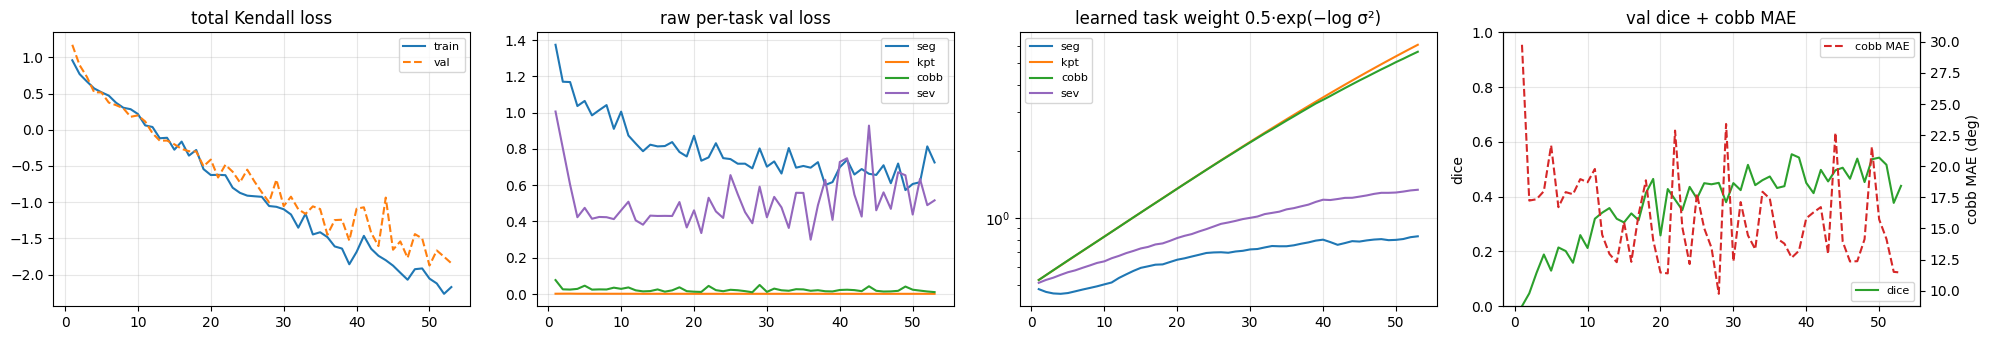

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.5))

ax = axes[0]
ax.plot(history_df["epoch"], history_df["train_loss"], label="train")
ax.plot(history_df["epoch"], history_df["val_loss"], label="val", linestyle="--")
ax.set_title("total Kendall loss"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for k, c in [("val_seg","tab:blue"), ("val_kpt","tab:orange"), ("val_cobb","tab:green"), ("val_sev","tab:purple")]:
    ax.plot(history_df["epoch"], history_df[k], label=k.replace("val_", ""), color=c)
ax.set_title("raw per-task val loss"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
for k, c in [("w_seg","tab:blue"), ("w_kpt","tab:orange"), ("w_cobb","tab:green"), ("w_sev","tab:purple")]:
    ax.plot(history_df["epoch"], history_df[k], label=k.replace("w_", ""), color=c)
ax.set_yscale("log")
ax.set_title("learned task weight 0.5·exp(−log σ²)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[3]
ax.plot(history_df["epoch"], history_df["val_dice"], color="tab:green", label="dice")
ax.set_ylim(0, 1); ax.set_ylabel("dice")
ax2 = ax.twinx()
ax2.plot(history_df["epoch"], history_df["val_cobb_mae"], color="tab:red", linestyle="--", label="cobb MAE")
ax2.set_ylabel("cobb MAE (deg)")
ax.set_title("val dice + cobb MAE"); ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=8); ax2.legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()

## 8 · Evaluation — Four Estimators of Severity

Now four routes from radiograph to severity:

1. **cobb_direct** → severity bucket
2. **cobb_from_seg** → severity bucket (existing tangent pipeline)
3. **cobb_from_kpt** → severity bucket (heatmap argmax + pairwise tilt)
4. **sev_head** — direct softmax (no Cobb pipeline)

Plus a 5th: **inverse-MAE-weighted ensemble** of the three Cobb estimators (the v1 winner).

In [16]:
def cobb_from_keypoints(coords_xy: np.ndarray, num_vert: int = NUM_VERT) -> float:
    angles = []
    for v in range(num_vert):
        tl, tr, bl, br = coords_xy[4 * v: 4 * v + 4]
        if np.isfinite(tl).all() and np.isfinite(tr).all():
            angles.append(math.degrees(math.atan2(tr[1] - tl[1], tr[0] - tl[0])))
        if np.isfinite(bl).all() and np.isfinite(br).all():
            angles.append(math.degrees(math.atan2(br[1] - bl[1], br[0] - bl[0])))
    a = np.array([x for x in angles if np.isfinite(x)])
    if len(a) < 2: return float("nan")
    return float(np.abs(a[:, None] - a[None, :]).max())

@torch.no_grad()
def evaluate_case(model, row):
    case = preprocess_case(row)
    out = model(case["image"].unsqueeze(0).to(DEVICE))
    seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
    kpt_hm = out["kpt"].squeeze(0).cpu()
    cobb_d = float(out["cobb"].squeeze(0).cpu())
    sev_logits = out["sev"].squeeze(0).cpu()
    sev_pred = SEVERITY_LABELS[int(sev_logits.argmax())]

    ds = []
    for c in range(1, NUM_SEG_CLASSES):
        p, g = (seg_pred == c), (case["seg"] == c)
        d = p.sum() + g.sum()
        if d > 0: ds.append(float(2.0 * (p & g).sum() / d))
    cobb_s = float(cobb_from_segmentation_tangent(seg_pred.numpy()))
    coords, _ = keypoints_from_heatmaps(kpt_hm)
    cobb_k = cobb_from_keypoints(coords)

    out_row = {
        "dice": float(np.mean(ds)) if ds else np.nan,
        "cobb_direct": cobb_d, "cobb_from_seg": cobb_s, "cobb_from_kpt": cobb_k,
        "sev_pred": sev_pred,
    }
    gt = row.get("cobb_angle_deg")
    if pd.notna(gt):
        gt = float(gt)
        out_row["cobb_true"] = gt
        out_row["sev_true"] = severity_name(gt)
        for k in ("cobb_direct", "cobb_from_seg", "cobb_from_kpt"):
            v = out_row[k]
            out_row[f"{k}_abs_err"] = abs(v - gt) if np.isfinite(v) else np.nan
    return out_row

eval_df = pd.DataFrame([evaluate_case(model, r) for _, r in VAL_DF.iterrows()])
print(f"evaluated {len(eval_df)} val cases")
eval_df.head()

evaluated 50 val cases


,dice,cobb_direct,cobb_from_seg,cobb_from_kpt,sev_pred,cobb_true,sev_true,cobb_direct_abs_err,cobb_from_seg_abs_err,cobb_from_kpt_abs_err
0,0.475650,81.120651,68.789386,48.887910,severe,80.171357,severe,0.949294,11.381971,31.283448
1,0.769949,43.002533,12.305736,36.422283,moderate,NaN,NaN,NaN,NaN,NaN
2,0.121171,93.368675,96.806939,26.565051,severe,90.000000,severe,3.368675,6.806939,63.434949
3,0.790857,46.017857,15.270062,71.760599,moderate,NaN,NaN,NaN,NaN,NaN
4,0.697431,57.846771,43.363944,86.820170,severe,37.935438,moderate,19.911333,5.428506,48.884732


In [17]:
summary = {"n_val": int(len(eval_df)), "mean_dice": float(eval_df["dice"].mean())}
with_gt = eval_df.dropna(subset=["cobb_true"]) if "cobb_true" in eval_df else pd.DataFrame()
if len(with_gt):
    summary["n_with_cobb_gt"] = int(len(with_gt))
    for col in ("cobb_direct", "cobb_from_seg", "cobb_from_kpt"):
        e = with_gt[f"{col}_abs_err"].dropna()
        if len(e):
            summary[f"{col}_mae"] = float(e.mean())
            summary[f"{col}_median"] = float(e.median())
            summary[f"{col}_r"] = float(with_gt[[col, "cobb_true"]].corr().iloc[0, 1])
    # ensembles
    mae_d = with_gt["cobb_direct_abs_err"].mean()
    mae_s = with_gt["cobb_from_seg_abs_err"].mean()
    mae_k = with_gt["cobb_from_kpt_abs_err"].mean()
    w_d, w_s, w_k = 1/mae_d, 1/mae_s, 1/mae_k
    wsum = w_d + w_s + w_k
    cobb_ens = (with_gt["cobb_direct"] * w_d + with_gt["cobb_from_seg"] * w_s + with_gt["cobb_from_kpt"] * w_k) / wsum
    summary["cobb_ensemble_mae"] = float((cobb_ens - with_gt["cobb_true"]).abs().mean())
    # severity
    summary["sev_head_acc"] = float((with_gt["sev_pred"] == with_gt["sev_true"]).mean())
    for col in ("cobb_direct", "cobb_from_seg", "cobb_from_kpt"):
        pred_sev = with_gt[col].apply(severity_name)
        summary[f"{col}_sev_acc"] = float((pred_sev == with_gt["sev_true"]).mean())

print("=== Multi-Task v2 ===")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"  {k:30s} {v:.3f}")
    else:
        print(f"  {k:30s} {v}")
print("\n=== v1 reference (best_val_dice 0.683) ===")
print("  cobb_direct      MAE=9.34°   r=0.838  sev_acc=0.844")
print("  cobb_from_seg    MAE=13.44°  r=0.748  sev_acc=0.812")
print("  cobb_from_kpt    MAE=19.69°  r=0.242  sev_acc=0.719")
print("  ensemble (inv-MAE wtd) MAE=8.25°")

=== Multi-Task v2 ===
  n_val                          50
  mean_dice                      0.529
  n_with_cobb_gt                 32
  cobb_direct_mae                12.648
  cobb_direct_median             13.080
  cobb_direct_r                  0.659
  cobb_from_seg_mae              10.356
  cobb_from_seg_median           7.731
  cobb_from_seg_r                0.783
  cobb_from_kpt_mae              25.147
  cobb_from_kpt_median           21.321
  cobb_from_kpt_r                -0.212
  cobb_ensemble_mae              10.875
  sev_head_acc                   0.719
  cobb_direct_sev_acc            0.812
  cobb_from_seg_sev_acc          0.844
  cobb_from_kpt_sev_acc          0.750

=== v1 reference (best_val_dice 0.683) ===
  cobb_direct      MAE=9.34°   r=0.838  sev_acc=0.844
  cobb_from_seg    MAE=13.44°  r=0.748  sev_acc=0.812
  cobb_from_kpt    MAE=19.69°  r=0.242  sev_acc=0.719
  ensemble (inv-MAE wtd) MAE=8.25°


## 9 · Conclusions

Fill in after first run.

- **Did Kendall rebalance the gradients?** Inspect the `w_seg / w_kpt / w_cobb / w_sev` curves. v1's effective ratio was 99 / 0.2 / 0.8 / — ; v2 ideally lands closer to equal-magnitude contributions.
- **Did the kpt path revive?** v1 baseline: 19.69° MAE, r=0.24. If v2 kpt drops below ~12° MAE → balance was the problem; keep the head. If still >18° → the head/algorithm is structurally weak; drop in v3.
- **Did rotation-aware Cobb supervision help the direct head?** v1 baseline 9.34°. If v2 lands ≤ 8.5° → confirmed.
- **Did the severity head match severity-from-Cobb?** Compare `sev_head_acc` against `cobb_direct_sev_acc` (v1: 0.844). If higher → direct severity classification beats Cobb regression for clinical decisioning.
- **Next pivot:** v3 should drop whatever didn't pay its way.